In [1]:
import jax
import jax.numpy as jnp
from jax import random
print(jax.devices())

import numpy as np
import dill

# change between lib_Adam_FF and lib_Adam_tanh
from lib.lib_Adam_FF import (
    Functions,
    AdamTrain,
    init_drift_params,
    init_diffusion_params
)

from lib.plot_lib import PlotResults
PR = PlotResults(Functions)

%load_ext autoreload
%autoreload 2

[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2)]


In [3]:
ex_name = "ex1"

# load true functions
with open(f"true_functions/{ex_name}.pkl", "rb") as f:
    true_functions = dill.load(f)

true_drift = true_functions["drift"]
true_diffusion = true_functions["diffusion"]

# load training data
training_data = np.load(f"training_data/{ex_name}.npz")

x = training_data["x_data"]
r = training_data["r_data"]
h = training_data["step_sizes"]
diff_type = str(training_data["diff_type"])
print(x.shape, r.shape, h.shape)

if x.ndim == 3:  # if training data is in trajectory form, take samples to obtain data triplets
    sample_rate = 1000
    x = x[:, :, ::sample_rate].reshape(-1, x.shape[1])
    r = r.reshape(r.shape[0], r.shape[1], r.shape[2] // sample_rate, sample_rate).sum(axis=3).reshape(-1, r.shape[1])
    h = h.reshape(h.shape[0], h.shape[1] // sample_rate, sample_rate).sum(axis=2)
    
print(x.shape, r.shape, h.shape)

(10000, 2, 1000) (10000, 2, 1000) (10000, 1000)
(10000, 2) (10000, 2) (10000, 1)


In [4]:
# random_indices = np.random.choice(x.shape[0], 100000, replace=False)
# x = x[random_indices, :]
# r = r[random_indices, :]
# h = h[random_indices, :]

In [13]:
# Adam parameters
hyperparams = {"epochs": 300, 
               "learning_rate": 1e-4, 
               "batch_size": 2**8, 
               "layer_widths": (2**10,)}  # (K,) for shallow, (K, ..., K) for deep

AdamTrain.set_opt(hyperparams)

In [20]:
# train model
key = random.PRNGKey(0)
key1, key2 = random.split(key, 2)
drift_param = init_drift_params(key1, hyperparams["layer_widths"], x.shape[1], r.shape[1])
diff_param = init_diffusion_params(key2, hyperparams["layer_widths"], x.shape[1], r.shape[1], diff_type)

Adam_drift_param, Adam_diff_param, times, losses, val_losses = AdamTrain.training_loop(hyperparams, drift_param, diff_param, x, r, h, diff_type, val_split=0.1, plot=False)


epoch 299: loss = -3.2876, val_loss = -3.0076, time = 3.6613s


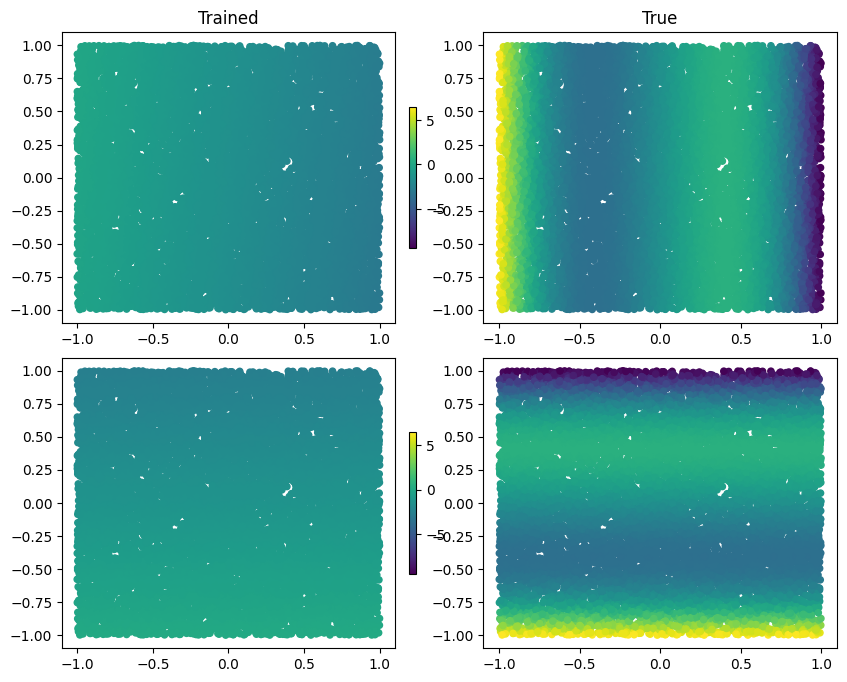

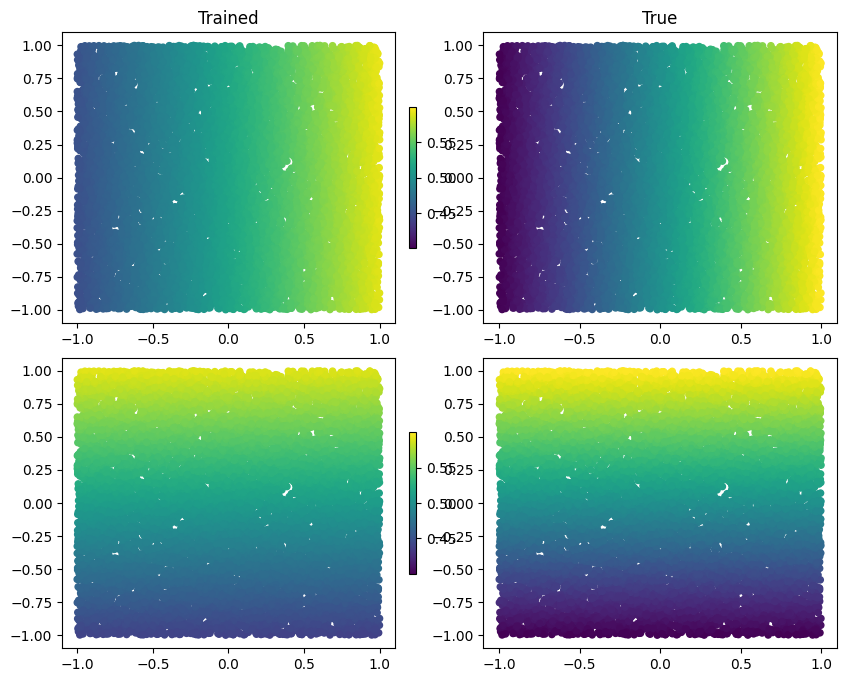

In [15]:
# figures to compare network and true functions
x_plot = x[np.random.choice(x.shape[0], 10000, replace=False), :]

PR.plot_train_v_true(Adam_drift_param, x_plot, true_func=true_drift)
PR.plot_train_v_true(Adam_diff_param, x_plot, diff_type=diff_type, true_func=true_diffusion)

In [16]:

#np.savez(f"saved_results/NN_param/{ex_name}_Adam.npz", drift_param=Adam_drift_param, diff_param=Adam_diff_param, diff_type=diff_type)


In [8]:
# train model
epochs = hyperparams["epochs"]
No_Exp = 10
training_times = np.zeros((No_Exp, epochs))
losses = np.zeros((No_Exp, epochs))
val_losses = np.zeros((No_Exp, epochs))

for i in range(No_Exp):
    #jax.clear_caches()  # reset compilations to include compilation time
    
    key = random.PRNGKey(i)
    key, key1, key2 = random.split(key, 3)
    drift_param = init_drift_params(key1, hyperparams["layer_widths"], x.shape[1], r.shape[1])
    diff_param = init_diffusion_params(key2, hyperparams["layer_widths"], x.shape[1], r.shape[1], diff_type)

    idx = jax.random.permutation(key, x.shape[0])
    x_ = x[idx]
    r_ = r[idx]
    h_ = h[idx]
    
    _, _, training_times[i,:], losses[i,:], val_losses[i,:] = AdamTrain.training_loop(hyperparams, drift_param, diff_param, x_, r_, h_, diff_type, val_split=0.1, plot=False)



epoch 0: loss = -6.3580, val_loss = -6.3252
epoch 0: loss = -6.3160, val_loss = -6.3356
epoch 0: loss = -6.2988, val_loss = -6.3362
epoch 0: loss = -6.3572, val_loss = -6.3491
epoch 0: loss = -6.3399, val_loss = -6.3405
epoch 0: loss = -6.3540, val_loss = -6.3517
epoch 0: loss = -6.3382, val_loss = -6.3227
epoch 0: loss = -6.3577, val_loss = -6.3376
epoch 0: loss = -6.3071, val_loss = -6.3512
epoch 0: loss = -6.3254, val_loss = -6.3322


In [9]:

#np.savez(f"saved_results/loss_time_data/raw_loss_data/{ex_name}_Adam.npz", training_times=training_times, val_losses=val_losses)
